# Cross validation of GPQR models for phi

In [ ]:
import sys
import os
import math

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Run cross validation

In [ ]:
from scripts.cv import split_data, cross_validate, cross_validate_gpr

QUANTILES = torch.tensor([0.05, 0.25, 0.5, 0.75, 0.95]).to(device)
CENTER_QUANTILE_INDEX = 2
NUM_LOWER_QUANTILES = 2
NUM_LATENTS = 3
NUM_LOWER_LATENTS = 1
K = 5

N_EPOCHS = int(os.getenv("HEAVYEDGE_N_EPOCHS", 10000))

X = pd.read_csv("../_temp/X.csv").drop(columns="Slurry").values
y = pd.read_csv("../_temp/y.csv")["phi"].values

x_train_cv, y_train_cv, x_test_cv, y_test_cv, x_scales, x_mins = split_data(
    X, y, K, device
)

### Basic GPR

In [ ]:
from scripts.all_models import GPR_phi
from gpytorch.likelihoods import GaussianLikelihood

CV_PATH = "../_temp/gpr_cv.phi.csv"

if os.path.exists(CV_PATH):
    gpr_cv = pd.read_csv(CV_PATH).values
else:
    likelihood = GaussianLikelihood(batch_shape=torch.Size([K])).to(device)
    gpr = GPR_phi(
        x_train_cv.clone().detach(),
        y_train_cv.clone().detach(),
        likelihood,
        X_scale=x_scales,
        X_min=x_mins,
        batch_shape=torch.Size([K]),
    ).to(device)

    gpr_cv = cross_validate_gpr(
        x_train_cv,
        y_train_cv,
        x_test_cv,
        y_test_cv,
        QUANTILES,
        gpr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(gpr_cv).to_csv(CV_PATH, index=False)

### Center-gap LMC

In [ ]:
from scripts.all_models import CgLmcMtgpqr_phi
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

CV_PATH = "../_temp/cg_lmc_cv.phi.csv"

if os.path.exists(CV_PATH):
    cg_lmc_cv = pd.read_csv(CV_PATH).values
else:
    cg_lmc_mtgpqr = CgLmcMtgpqr_phi(
        inducing_points=x_train_cv.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales,
        X_min=x_mins,
        batch_shape=torch.Size([K]),
    ).to(device)
    likelihood = MultitaskCenterGapQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        CENTER_QUANTILE_INDEX,
        torch.zeros((K, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    cg_lmc_cv = cross_validate(
        x_train_cv,
        y_train_cv,
        x_test_cv,
        y_test_cv,
        QUANTILES,
        cg_lmc_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(cg_lmc_cv).to_csv(CV_PATH, index=False)

### Center-gap independent

In [ ]:
from scripts.all_models import CgIndependentMtgpqr_phi
from gpytorch_qr.likelihoods import MultitaskCenterGapQuantileGPLikelihood

CV_PATH = "../_temp/cg_independent_cv.phi.csv"

if os.path.exists(CV_PATH):
    cg_independent_cv = pd.read_csv(CV_PATH).values
else:
    cg_independent_mtgpqr = CgIndependentMtgpqr_phi(
        inducing_points=x_train_cv.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales,
        X_min=x_mins,
        batch_shape=torch.Size([K]),
    ).to(device)
    likelihood = MultitaskCenterGapQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        CENTER_QUANTILE_INDEX,
        torch.zeros((K, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    cg_independent_cv = cross_validate(
        x_train_cv,
        y_train_cv,
        x_test_cv,
        y_test_cv,
        QUANTILES,
        cg_independent_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(cg_independent_cv).to_csv(CV_PATH, index=False)

### Direct LMC

In [ ]:
from scripts.all_models import DirectLmcMtgpqr_phi
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

CV_PATH = "../_temp/direct_lmc_cv.phi.csv"

if os.path.exists(CV_PATH):
    direct_lmc_cv = pd.read_csv(CV_PATH).values
else:
    direct_lmc_mtgpqr = DirectLmcMtgpqr_phi(
        inducing_points=x_train_cv.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales,
        X_min=x_mins,
        batch_shape=torch.Size([K]),
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        torch.zeros((K, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    direct_lmc_cv = cross_validate(
        x_train_cv,
        y_train_cv,
        x_test_cv,
        y_test_cv,
        QUANTILES,
        direct_lmc_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(direct_lmc_cv).to_csv(CV_PATH, index=False)

### Direct independent

In [ ]:
from scripts.all_models import DirectIndependentMtgpqr_phi
from gpytorch_qr.likelihoods import MultitaskQuantileGPLikelihood

CV_PATH = "../_temp/direct_independent_cv.phi.csv"

if os.path.exists(CV_PATH):
    direct_independent_cv = pd.read_csv(CV_PATH).values
else:
    direct_independent_mtgpqr = DirectIndependentMtgpqr_phi(
        inducing_points=x_train_cv.clone().detach(),
        num_quantiles=len(QUANTILES),
        num_lower_quantiles=NUM_LOWER_QUANTILES,
        num_latents=NUM_LATENTS,
        num_lower_latents=NUM_LOWER_LATENTS,
        X_scale=x_scales,
        X_min=x_mins,
        batch_shape=torch.Size([K]),
    ).to(device)
    likelihood = MultitaskQuantileGPLikelihood(
        QUANTILES.unsqueeze(0),
        torch.zeros((K, len(QUANTILES))),
        learn_scales=True,
    ).to(device)

    direct_independent_cv = cross_validate(
        x_train_cv,
        y_train_cv,
        x_test_cv,
        y_test_cv,
        QUANTILES,
        direct_independent_mtgpqr,
        likelihood,
        n_epochs=N_EPOCHS,
    )

    pd.DataFrame(direct_independent_cv).to_csv(CV_PATH, index=False)

## Plot

In [ ]:
def sci_label(value: float, precision: int = 2) -> str:
    if value == 0:
        return f"{0:.{precision}f} × 10^0"
    exponent = math.floor(math.log10(abs(value)))
    mantissa = value / (10**exponent)
    return f"{mantissa:.{precision}f} × 10^{exponent}"

### CV loss by epoch

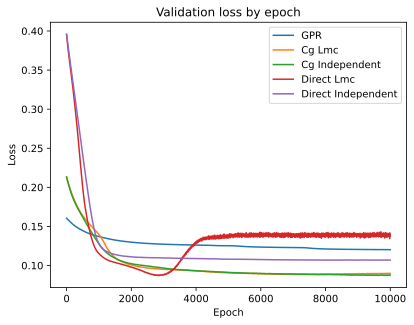

In [ ]:
plt.plot(gpr_cv.mean(axis=1), label="GPR")
plt.plot(cg_lmc_cv.mean(axis=1), label="Cg Lmc")
plt.plot(cg_independent_cv.mean(axis=1), label="Cg Independent")
plt.plot(direct_lmc_cv.mean(axis=1), label="Direct Lmc")
plt.plot(direct_independent_cv.mean(axis=1), label="Direct Independent")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation loss by epoch")
plt.legend()
plt.show()

### Minimum CV loss

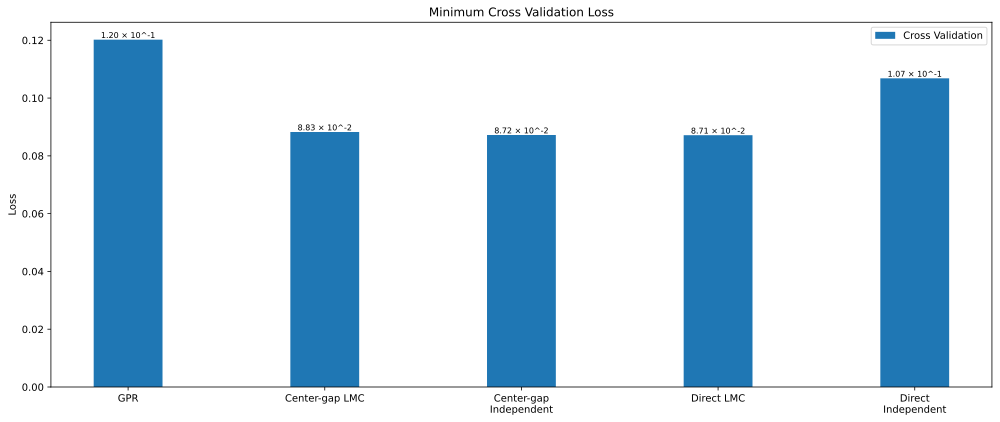

In [ ]:
names = [
    "GPR",
    "Center-gap LMC",
    "Center-gap\nIndependent",
    "Direct LMC",
    "Direct\nIndependent",
]
cv_losses = [
    gpr_cv.mean(axis=1).min(),
    cg_lmc_cv.mean(axis=1).min(),
    cg_independent_cv.mean(axis=1).min(),
    direct_lmc_cv.mean(axis=1).min(),
    direct_independent_cv.mean(axis=1).min(),
]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars_cv = ax.bar(x, cv_losses, width, label="Cross Validation")

for bar in list(bars_cv):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        sci_label(height),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Loss")
ax.set_title("Minimum Cross Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

### Best epoch

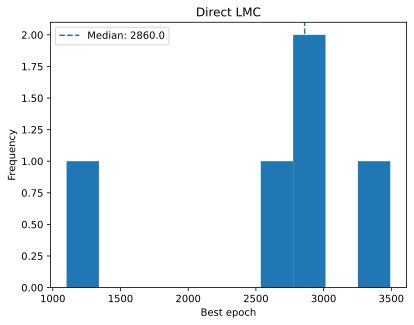

In [ ]:
direct_lmc_best_epochs = direct_lmc_cv.argmin(axis=0)
direct_lmc_epoch = np.median(direct_lmc_best_epochs)

plt.hist(direct_lmc_best_epochs)
plt.axvline(direct_lmc_epoch, ls="--", label=f"Median: {direct_lmc_epoch}")

plt.xlabel("Best epoch")
plt.ylabel("Frequency")
plt.title("Direct LMC")
plt.legend()
plt.show()